# 微笑模拟tob图片版1.0

In [27]:
import os
import glob
import base64
import time
import requests
import json
import trimesh
import urllib
import numpy as np
import DracoPy
from PIL import Image
from io import BytesIO
import cv2
import glob
import matplotlib.pyplot as plt

## 定义调用规则

In [28]:
# 朝厚服务请求地址，随api文档发送
base_url = "<服务请求地址>"

# 朝厚文件服务地址，随api文档发送
file_server_url = "<服务文件服务器地址>"

# 必须传入鉴权 Header。请保护好TOKEN!!! 如果泄露请立即联系我们重置，所有使用该TOKEN的任务都会向您的账户计费
zh_token = "<贵司服务Token, 随合同发送>" # 调用所有的API都必须传入token用作鉴权

user_group = "APIClient" # 用户组，一般为 APIClient

# 贵司user_id, 随api文档发送
user_id = "<贵司user_id>"

# 如果您收到了creds.json, 下面将直接读取
if os.path.exists('../../creds.json'):
    creds = json.load(open('../../creds.json', 'r'))
    base_url = creds['base_url']
    file_server_url = creds['file_server_url']
    zh_token = creds['zh_token']
    user_id = creds['user_id']
    print("loaded creds from creds.json")

loaded creds from creds.json


In [29]:
def upload_file(file_name):
    ext = file_name.split('.')[-1]
    data = open('../../data/' + file_name, 'rb').read()
    resp = requests.get(file_server_url + f"/scratch/{user_group}/{user_id}/upload_url?" +
                        f"postfix={ext}", # 必须指定 postfix, 即文件后缀名
                        headers={"X-ZH-TOKEN": zh_token}) # 获取带签名的上传地址
    resp.raise_for_status()

    upload_url = resp.text[1:-1] # 返回为一个单字符串JSON "string", 这里也可以用json.loads(resp.text)

    resp = requests.put(upload_url, data) # 上传至云储存服务不需要带鉴权头

    resp.raise_for_status()
    path = "/".join(urllib.parse.urlparse(upload_url).path.lstrip("/").split("/")[3:])
    urn = f"urn:zhfile:o:s:{user_group}:{user_id}:{path}"
    return urn

def run_job_and_get_results(json_call, timeout_sec):
    headers = {
      "Content-Type": "application/json",
      "X-ZH-TOKEN": zh_token
    }

    url = base_url + '/run'

    response = requests.request("POST", url, headers=headers, data=json.dumps(json_call))
    response.raise_for_status()
    create_result = response.json()
    run_id = create_result['run_id']
    print("workflow id is", run_id)
    url = base_url + f"/run/{run_id}"

    start_time = time.time()
    while time.time()-start_time < timeout_sec:
        time.sleep(0.3)
        response = requests.request("GET", url, headers=headers)
        result = response.json()
        if result['completed'] or result['failed']:
            break

    if not result['completed']:
        if result['failed']:
            raise ValueError("API failed due to " + str(result['reason_public']))
        raise TimeoutError("API timeout")

    print("API finished in {}s".format(time.time()-start_time))
    url = base_url + f"/data/{run_id}"
    response = requests.request("GET", url, headers=headers)
    return response.json()

def retrieve_mesh(mesh_file_json):
    resp = requests.get(file_server_url + f"/file/download?" + urllib.parse.urlencode({
                        "urn": mesh_file_json['data']}),
                        headers={"X-ZH-TOKEN": zh_token})
    return trimesh.load(trimesh.util.wrap_as_stream(resp.content), file_type=mesh_file_json['type'])

def show_img(urn):
    imbytes = requests.get(file_server_url + f"/file/download?" + urllib.parse.urlencode({
                        "urn": urn}),
                        headers={"X-ZH-TOKEN": zh_token}).content
    imarray = np.asarray(bytearray(imbytes), dtype=np.uint8)
    plt.imshow(cv2.imdecode(imarray, cv2.IMREAD_COLOR)[...,::-1])

## 生成自动加工单与目标位

In [30]:
json_call = {
  "spec_group": "mesh-processing",
  "spec_name": "oral-arrangement-medical",
  "spec_version": "1.0-snapshot",
  "user_group": user_group,
  "user_id": user_id,
  "input_data": {
      "upper_mesh": {"type":"drc", "data": upload_file("upper_jaw_scan.drc")},
      "lower_mesh": {"type":"ply", "data": upload_file("lower_jaw_scan.ply")},
      "ceph": upload_file("ceph.jpg"),
      "smile_photo": upload_file("face_smile.jpg"),
  },
  'output_config': {
    "u_teeth_comp": {"type": "ply"},
    "l_teeth_comp": {"type": "ply"}
  }
}
result_arrangement = run_job_and_get_results(json_call, 1200)

workflow id is wf_1766750235-e3f4736b-8da9-4b22-8bcc-5d46ba48f2f1
API finished in 131.00281882286072s


## 生成分步信息

In [31]:
json_call = {
  "spec_group": "mesh-processing", # 调用的工作流组， 随API文档发送
  "spec_name": "auto-step", # 调用的工作流名称， 随API文档发送, 
  "spec_version": "1.0-snapshot", # 调用的工作流版本，随API文档发送
  "user_group": user_group,
  "user_id": user_id
}
json_call["input_data"] = {
    "upper_teeth_dict": result_arrangement["u_teeth_comp"],
    "upper_align_matrix": result_arrangement["u_align_matrix"],
    "upper_axis_matrix_dict": result_arrangement["u_axis"],
    "lower_teeth_dict": result_arrangement["l_teeth_comp"],
    "lower_align_matrix": result_arrangement["l_align_matrix"],
    "lower_axis_matrix_dict": result_arrangement["l_axis"],
    "transformation_dict": result_arrangement['transformation_dict']
}
result_step = run_job_and_get_results(json_call, 2200)

workflow id is sa_service_1766750367-32607825-f49d-4bba-a082-d940d8ca6899
API finished in 54.43043494224548s


### 检测自动分步的结果step_dict是否符合smile-tob的输入

In [32]:
step_dict = result_step['result']['step_dict']
print(f"从 auto-step 获取的 step_dict 类型: {type(step_dict)}")
print(f"step_dict 长度: {len(step_dict)}")

从 auto-step 获取的 step_dict 类型: <class 'list'>
step_dict 长度: 18


In [33]:
if step_dict and isinstance(step_dict, list):
    first_step = step_dict[0]
    print(f"第一个step的类型: {type(first_step)}")
    if isinstance(first_step, dict):
        print(f"第一个step中的牙齿数量: {len(first_step)}")
        sample_key = list(first_step.keys())[0] if first_step else None
        if sample_key:
            print(f"示例牙齿编号: {sample_key} (类型: {type(sample_key)})")
            matrix = first_step[sample_key]
            print(f"矩阵形状: {len(matrix)}x{len(matrix[0])}")

第一个step的类型: <class 'dict'>
第一个step中的牙齿数量: 27
示例牙齿编号: 11 (类型: <class 'str'>)
矩阵形状: 4x4


In [34]:
u_teeth_comp = result_arrangement["u_teeth_comp"]
l_teeth_comp = result_arrangement["l_teeth_comp"]

# 合并上下颌牙齿
all_teeth = {**u_teeth_comp, **l_teeth_comp}
print(f"牙齿模型数量: {len(all_teeth)}")

牙齿模型数量: 27


## 微笑模拟tob图片版1.0

该接口用于模拟患者矫正过后的张口效果，本算法会严格按照排牙方案目标位（或中间步骤）生成牙齿  https://www.chohotech.com/docs/cloud-zh/#/module/smile-tob-simulation-1

In [ ]:
json_call = {
  "spec_group": "smile",
  "spec_name": "smile-tob-simulation",
  "spec_version": "1.0-snapshot",
  "user_group": user_group,
  "user_id": user_id,
  "input_data": {
      "image": upload_file("face_smile.jpg"),
      "meshes": all_teeth,  # 牙齿模型字典
      "step_dict": step_dict,  # 使用数组格式
      "keep_size": False  # 可选参数
  }
}
# 打印调试信息
print("请求已构建:")
print(f"- meshes 数量: {len(all_teeth)}")
print(f"- step_dict 长度: {len(step_dict)}")

请求已构建:
- meshes 数量: 27
- step_dict 长度: 18


In [42]:
# 执行API调用
try:
    result_sim = run_job_and_get_results(json_call, 1000)
    print(f"\n成功! 结果: {result_sim}")
except Exception as e:
    print(f"\n调用失败: {e}")
    
    # 如果是HTTP错误，打印详细信息
    if hasattr(e, 'response'):
        print(f"状态码: {e.response.status_code}")
        print(f"错误详情: {e.response.text}")

workflow id is sa_service_1766750658-6c3d7285-8e1d-4d5e-b06b-a4a96b05814a
API finished in 8.40118670463562s

成功! 结果: {'result': {'image': ['urn:zhfile:o:wfd:APIClient:ZH-api:wfdata/sa_service_1766750658-6c3d7285-8e1d-4d5e-b06b-a4a96b05814a/output-files/result/image/0']}}


# 可视化结果

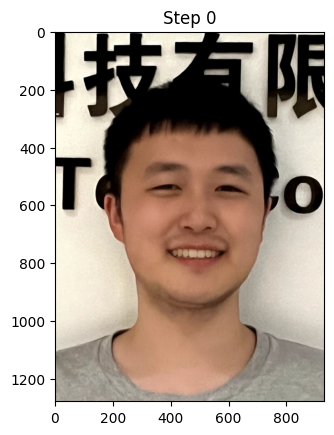

In [43]:
for i, urn in enumerate(result_sim['result']['image']):
    plt.figure()
    plt.title(f"Step {i}")
    show_img(urn)  # urn 是图片的URN字符串
    plt.show()